<a href="https://colab.research.google.com/github/moulikagurram83/bapatla-salinity-mapping/blob/main/Model_Training_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
import torch, numpy as np, rasterio, pickle, os, shutil
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import torch.nn as nn
from rasterio.windows import Window
import gc

drive.mount('/content/drive', force_remount=False)
os.makedirs('/content/data/maps', exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

DRIVE = '/content/drive/MyDrive/SalinityProject/'

# ── Copy small files only — NOT the feature stack ────────────
for src, dst in [
    (DRIVE+'best_model.pt',    '/content/data/best_model.pt'),
    (DRIVE+'scaler_fixed.pkl', '/content/data/scaler_fixed.pkl'),
    (DRIVE+'calibration.pkl',  '/content/data/calibration.pkl'),
]:
    if not os.path.exists(dst):
        shutil.copy(src, dst)
        print(f"✓ Copied {os.path.basename(dst)}")
    else:
        print(f"✓ Already local: {os.path.basename(dst)}")

# ── Load calibration + scaler ─────────────────────────────────
with open('/content/data/calibration.pkl','rb') as f: cal = pickle.load(f)
with open('/content/data/scaler_fixed.pkl','rb') as f: scaler = pickle.load(f)
print(f"✓ Calibration: EC = {cal['slope']:.3f} × pred + {cal['intercept']:.3f}")

# ── Build model ───────────────────────────────────────────────
class AttentionLayer(nn.Module):
    def __init__(self, h):
        super().__init__()
        self.a = nn.Sequential(nn.Linear(h,h//2),nn.Tanh(),nn.Linear(h//2,1))
    def forward(self, x):
        w = torch.softmax(self.a(x), dim=1)
        return (x*w).sum(dim=1), w

class CNN_BiLSTM_Attention(nn.Module):
    def __init__(self, ni=5, ny=14, ns=3, cf=64, lh=128, ll=2, dr=0.3):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(ni,cf,3,padding=1),nn.BatchNorm1d(cf),nn.ReLU(),
            nn.Conv1d(cf,cf*2,3,padding=1),nn.BatchNorm1d(cf*2),nn.ReLU(),
            nn.Dropout(dr))
        self.lstm = nn.LSTM(cf*2,lh,ll,batch_first=True,
                            bidirectional=True,dropout=dr if ll>1 else 0)
        self.attn = AttentionLayer(lh*2)
        self.sfc  = nn.Sequential(nn.Linear(ns,32),nn.ReLU(),nn.Dropout(dr))
        self.reg  = nn.Sequential(
            nn.Linear(lh*2+32,128),nn.ReLU(),nn.Dropout(dr),
            nn.Linear(128,64),nn.ReLU(),nn.Linear(64,1))
    def forward(self, xt, xs):
        x = self.cnn(xt.permute(0,2,1)).permute(0,2,1)
        x,_ = self.lstm(x)
        c,w = self.attn(x)
        return self.reg(torch.cat([c,self.sfc(xs)],1)).squeeze(1), w

model = CNN_BiLSTM_Attention(ni=5,ny=14,ns=3).to(device)
model.load_state_dict(torch.load('/content/data/best_model.pt', map_location=device))
model.eval()
print("✓ Model loaded!")

Mounted at /content/drive
Device: cuda
✓ Copied best_model.pt
✓ Copied scaler_fixed.pkl
✓ Copied calibration.pkl
✓ Calibration: EC = -6.634 × pred + 34.501
✓ Model loaded!


In [ ]:
def predict_tiled(feature_path, scaler, model, cal, output_path,
                  tile_rows=200, n_yr=14, n_idx=5,
                  device='cuda', batch=2048, mode='2024'):
    """
    Predicts EC map tile by tile — never loads full raster into RAM.
    tile_rows: number of rows per tile (reduce if still crashing)
    """
    with rasterio.open(feature_path) as src:
        H, W     = src.height, src.width
        meta     = src.meta.copy()
        n_bands  = src.count
        transform = src.transform

    print(f"Raster size: {H}×{W} = {H*W:,} pixels")
    print(f"Processing in tiles of {tile_rows} rows")
    print(f"Total tiles: {int(np.ceil(H/tile_rows))}")

    # Prepare output raster
    meta_out = meta.copy()
    meta_out.update({'count':1, 'dtype':'float32', 'compress':'lzw'})

    with rasterio.open(output_path, 'w', **meta_out) as dst:
        n_tiles = int(np.ceil(H / tile_rows))

        for tile_idx in range(n_tiles):
            row_start = tile_idx * tile_rows
            row_end   = min(row_start + tile_rows, H)
            rows_this = row_end - row_start

            # Read only this tile from Drive — no full load!
            window = Window(0, row_start, W, rows_this)

            with rasterio.open(feature_path) as src:
                tile = src.read(window=window).astype(np.float32)

            tile = np.nan_to_num(tile, nan=0.0, posinf=0.0, neginf=0.0)

            # For 2030 — apply trend to tile
            if mode == '2030':
                tile = apply_trend_to_tile(tile, n_yr, n_idx)

            # Flatten tile pixels
            nb, th, tw = tile.shape
            X = tile.reshape(nb, -1).T    # [th*tw, bands]

            # Normalize
            X_sc = scaler.transform(X)
            X_t  = X_sc[:, :n_yr*n_idx].reshape(-1, n_yr, n_idx)
            X_s  = X_sc[:, n_yr*n_idx:]

            # Predict in batches
            preds = []
            for i in range(0, len(X_t), batch):
                xt = torch.FloatTensor(X_t[i:i+batch]).to(device)
                xs = torch.FloatTensor(X_s[i:i+batch]).to(device)
                with torch.no_grad():
                    p,_ = model(xt, xs)
                    preds.extend(p.cpu().numpy())
                del xt, xs

            preds = np.array(preds, dtype=np.float32)

            # Apply calibration
            preds_cal = np.clip(
                cal['slope']*preds + cal['intercept'], 0, 10
            ).reshape(1, rows_this, W)

            # Write tile to output file
            dst.write(preds_cal, window=window)

            # Free memory
            del tile, X, X_sc, X_t, X_s, preds, preds_cal
            gc.collect()
            torch.cuda.empty_cache()

            print(f"  Tile {tile_idx+1}/{n_tiles} done "
                  f"(rows {row_start}–{row_end})", end='\r')

    print(f"\n✓ Prediction complete → {output_path}")
    return output_path

In [ ]:
def apply_trend_to_tile(tile, n_yr=14, n_idx=5, years_ahead=6):
    """Apply temporal trend to project features to 2030."""
    last3_mean  = tile[(n_yr-3)*n_idx : n_yr*n_idx].mean(axis=0)
    early3_mean = tile[0 : 3*n_idx].mean(axis=0)
    trend       = (last3_mean - early3_mean) / (n_yr - 3)

    tile_2030 = tile.copy()
    for yr in range(n_yr):
        tile_2030[yr*n_idx:(yr+1)*n_idx] += trend * years_ahead

    return np.clip(np.nan_to_num(tile_2030, nan=0.0), -3, 3)

In [ ]:
import time

feature_path = DRIVE + 'bapatla_feature_stack_2010_2024.tif'
out_2024     = '/content/data/maps/bapatla_ec_2024.tif'
out_2030     = '/content/data/maps/bapatla_ec_2030.tif'

def predict_tiled_timed(feature_path, scaler, model, cal, output_path,
                        tile_rows=150, n_yr=14, n_idx=5,
                        device='cuda', batch=2048, mode='2024'):

    with rasterio.open(feature_path) as src:
        H, W    = src.height, src.width
        meta    = src.meta.copy()
        n_bands = src.count

    n_tiles  = int(np.ceil(H / tile_rows))
    meta_out = meta.copy()
    meta_out.update({'count':1, 'dtype':'float32', 'compress':'lzw'})

    print(f"Raster : {H}×{W} = {H*W:,} pixels")
    print(f"Tiles  : {n_tiles}  ({tile_rows} rows each)")
    print(f"Mode   : {mode}")
    print("-"*55)

    start_total = time.time()

    with rasterio.open(output_path, 'w', **meta_out) as dst:
        for tile_idx in range(n_tiles):
            tile_start = time.time()
            row_start  = tile_idx * tile_rows
            row_end    = min(row_start + tile_rows, H)
            rows_this  = row_end - row_start

            # Read tile
            window = Window(0, row_start, W, rows_this)
            with rasterio.open(feature_path) as src:
                tile = src.read(window=window).astype(np.float32)

            tile = np.nan_to_num(tile, nan=0.0, posinf=0.0, neginf=0.0)

            # Apply 2030 trend if needed
            if mode == '2030':
                tile = apply_trend_to_tile(tile, n_yr, n_idx)

            # Flatten + normalize
            nb, th, tw = tile.shape
            X    = tile.reshape(nb, -1).T
            X_sc = scaler.transform(X)
            X_t  = X_sc[:, :n_yr*n_idx].reshape(-1, n_yr, n_idx)
            X_s  = X_sc[:, n_yr*n_idx:]

            # Predict
            preds = []
            for i in range(0, len(X_t), batch):
                xt = torch.FloatTensor(X_t[i:i+batch]).to(device)
                xs = torch.FloatTensor(X_s[i:i+batch]).to(device)
                with torch.no_grad():
                    p,_ = model(xt, xs)
                    preds.extend(p.cpu().numpy())
                del xt, xs

            preds     = np.array(preds, dtype=np.float32)
            preds_cal = np.clip(
                cal['slope']*preds + cal['intercept'], 0, 10
            ).reshape(1, rows_this, W)

            dst.write(preds_cal, window=window)

            # Free memory
            del tile, X, X_sc, X_t, X_s, preds, preds_cal
            gc.collect()
            torch.cuda.empty_cache()

            # ── Time estimate ──────────────────────────────
            tile_time    = time.time() - tile_start
            elapsed      = time.time() - start_total
            remaining    = tile_time * (n_tiles - tile_idx - 1)
            done_pct     = (tile_idx+1) / n_tiles * 100

            mins_elapsed   = int(elapsed // 60)
            secs_elapsed   = int(elapsed % 60)
            mins_remaining = int(remaining // 60)
            secs_remaining = int(remaining % 60)

            print(f"Tile {tile_idx+1:>2}/{n_tiles}  "
                  f"[{'█'*int(done_pct//5):<20}] {done_pct:5.1f}%  "
                  f"Elapsed: {mins_elapsed}m{secs_elapsed:02d}s  "
                  f"ETA: {mins_remaining}m{secs_remaining:02d}s")

    total_time = time.time() - start_total
    print(f"\n✓ Done!  Total time: {int(total_time//60)}m {int(total_time%60):02d}s")
    print(f"  Saved: {output_path}")
    return output_path


# ── Run 2024 ──────────────────────────────────────────────────
print("="*55)
print("GENERATING 2024 SALINITY MAP")
print("="*55)
predict_tiled_timed(feature_path, scaler, model, cal,
                    out_2024, tile_rows=150,
                    mode='2024', device=device)

# ── Run 2030 ──────────────────────────────────────────────────
print("\n" + "="*55)
print("GENERATING 2030 SALINITY MAP")
print("="*55)
predict_tiled_timed(feature_path, scaler, model, cal,
                    out_2030, tile_rows=150,
                    mode='2030', device=device)


GENERATING 2024 SALINITY MAP
Raster : 2970×3340 = 9,919,800 pixels
Tiles  : 20  (150 rows each)
Mode   : 2024
-------------------------------------------------------
Tile  1/20  [█                   ]   5.0%  Elapsed: 0m14s  ETA: 4m42s
Tile  2/20  [██                  ]  10.0%  Elapsed: 0m29s  ETA: 4m25s
Tile  3/20  [███                 ]  15.0%  Elapsed: 0m42s  ETA: 3m36s
Tile  4/20  [████                ]  20.0%  Elapsed: 0m58s  ETA: 4m14s
Tile  5/20  [█████               ]  25.0%  Elapsed: 1m11s  ETA: 3m15s
Tile  6/20  [██████              ]  30.0%  Elapsed: 1m28s  ETA: 3m57s
Tile  7/20  [███████             ]  35.0%  Elapsed: 1m44s  ETA: 3m31s
Tile  8/20  [████████            ]  40.0%  Elapsed: 1m57s  ETA: 2m37s
Tile  9/20  [█████████           ]  45.0%  Elapsed: 2m13s  ETA: 2m52s
Tile 10/20  [██████████          ]  50.0%  Elapsed: 2m26s  ETA: 2m12s
Tile 11/20  [███████████         ]  55.0%  Elapsed: 2m46s  ETA: 2m57s
Tile 12/20  [████████████        ]  60.0%  Elapsed: 3m02s  ETA: 

'/content/data/maps/bapatla_ec_2030.tif'

In [ ]:
import numpy as np
import rasterio
from rasterio.windows import Window
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import pandas as pd
import gc, os, shutil

DRIVE = '/content/drive/MyDrive/SalinityProject/'
os.makedirs('/content/data/maps', exist_ok=True)

# Output paths for the EC maps generated in the previous cell.
ec_map_2024_path = '/content/data/maps/bapatla_ec_2024.tif'
ec_map_2030_path = '/content/data/maps/bapatla_ec_2030.tif'

# Define output paths for classification maps
class_map_2024_path = '/content/data/maps/bapatla_class_2024.tif'
class_map_2030_path = '/content/data/maps/bapatla_class_2030.tif'

def create_class_map(ec_src_path, class_dst_path, tile_rows=300):
    """
    Converts an EC map into a classification map based on predefined EC ranges.
    EC ranges: '< 2','2–4','4–8','8–16','> 16' corresponding to classes 1-5.
    Values predicted were clipped to 0-10, so class 5 (EC >= 16) will likely be empty.
    Values 8-10 will fall into class 4 (8-16 range).
    """
    if os.path.exists(class_dst_path):
        print(f"✓ Class map already exists: {os.path.basename(class_dst_path)}")
        return class_dst_path

    with rasterio.open(ec_src_path) as src:
        H, W = src.height, src.width
        meta = src.meta.copy()

    # Prepare output raster metadata for a single band, uint8 classification
    meta_out = meta.copy()
    meta_out.update({'count': 1, 'dtype': 'uint8', 'compress': 'lzw'})

    print(f"\nCreating class map from {os.path.basename(ec_src_path)}...")
    print(f"Output: {os.path.basename(class_dst_path)}")
    print(f"Raster size: {H}×{W} = {H*W:,} pixels")
    print(f"Processing in tiles of {tile_rows} rows")

    # Define thresholds for classification. Class IDs start from 1.
    # [Class 1: <2), [Class 2: 2-4), [Class 3: 4-8), [Class 4: 8-16), [Class 5: >=16)
    thresholds = [2.0, 4.0, 8.0, 16.0]

    with rasterio.open(class_dst_path, 'w', **meta_out) as dst:
        n_tiles = int(np.ceil(H / tile_rows))
        for tile_idx in range(n_tiles):
            row_start = tile_idx * tile_rows
            row_end = min(row_start + tile_rows, H)
            rows_this = row_end - row_start

            window = Window(0, row_start, W, rows_this)

            with rasterio.open(ec_src_path) as src_ec:
                ec_tile = src_ec.read(1, window=window)

            class_tile = np.zeros_like(ec_tile, dtype=np.uint8) # Default to Class 0 (No Data)

            # Classify based on EC values
            class_tile[ec_tile < thresholds[0]] = 1
            class_tile[(ec_tile >= thresholds[0]) & (ec_tile < thresholds[1])] = 2
            class_tile[(ec_tile >= thresholds[1]) & (ec_tile < thresholds[2])] = 3
            class_tile[(ec_tile >= thresholds[2]) & (ec_tile < thresholds[3])] = 4
            class_tile[ec_tile >= thresholds[3]] = 5 # Should handle EC >= 16

            # NaN values are already 0 from np.zeros_like initialization
            # For statistics, we assume class 0 is 'no data' and not a valid salinity class.

            dst.write(class_tile, 1, window=window)

            del ec_tile, class_tile
            gc.collect()

            print(f"  Tile {tile_idx+1}/{n_tiles} done "
                  f"(rows {row_start}–{row_end})", end='\r')
    print(f"\n✓ Class map created → {class_dst_path}")
    return class_dst_path

# --- Generate classification maps ---
# Ensure EC maps are present locally before attempting to create class maps
# (they should be from the previous cell execution)
if not os.path.exists(ec_map_2024_path):
    print(f"Error: EC map not found: {ec_map_2024_path}. Please run previous cells.")
if not os.path.exists(ec_map_2030_path):
    print(f"Error: EC map not found: {ec_map_2030_path}. Please run previous cells.")

create_class_map(ec_map_2024_path, class_map_2024_path)
create_class_map(ec_map_2030_path, class_map_2030_path)


names  = ['Non-saline','Slightly saline','Moderately saline',
          'Strongly saline','Extremely saline']
colors = ['#1a9641','#a6d96a','#fdae61','#d73027','#7b0000']
ec_ranges = ['< 2','2–4','4–8','8–16','> 16']

def get_class_stats(class_tif, pixel_size_m=30):
    """Read class map in tiles and compute area statistics."""
    counts = np.zeros(6, dtype=np.int64) # Index 0 for NoData, 1-5 for classes
    with rasterio.open(class_tif) as src:
        H, W = src.height, src.width
        tile_rows = 300
        for row_start in range(0, H, tile_rows):
            row_end = min(row_start+tile_rows, H)
            window  = Window(0, row_start, W, row_end-row_start)
            tile    = src.read(1, window=window) # Read the single classification band
            for c in range(6): # Iterate for classes 0 to 5
                counts[c] += (tile == c).sum()
            del tile
            gc.collect()

    total_valid = counts[1:].sum() # Sum of classes 1 through 5, excluding 0 (NoData)
    pixel_area  = pixel_size_m * pixel_size_m / 1e6   # km²

    results = []
    # Loop from 1 to 5 for class IDs
    for i, (name, ec_r) in enumerate(zip(names, ec_ranges), 1):
        count   = counts[i]
        area    = count * pixel_area
        # Handle case where total_valid might be zero to avoid division by zero
        pct     = (count / total_valid * 100) if total_valid > 0 else 0.0
        results.append({
            'class_id'    : i,
            'class_name'  : name,
            'ec_range'    : ec_r,
            'pixels'      : count,
            'area_km2'    : area,
            'percentage'  : pct
        })
    return pd.DataFrame(results), total_valid * pixel_area

print("\nComputing 2024 statistics...")
df_2024, total_area = get_class_stats(class_map_2024_path)
print("Computing 2030 statistics...")
df_2030, _          = get_class_stats(class_map_2030_path)

print("\n✓ Statistics computed!")
print(f"Total study area: {total_area:.1f} km²")


Creating class map from bapatla_ec_2024.tif...
Output: bapatla_class_2024.tif
Raster size: 2970×3340 = 9,919,800 pixels
Processing in tiles of 300 rows
  Tile 10/10 done (rows 2700–2970)
✓ Class map created → /content/data/maps/bapatla_class_2024.tif

Creating class map from bapatla_ec_2030.tif...
Output: bapatla_class_2030.tif
Raster size: 2970×3340 = 9,919,800 pixels
Processing in tiles of 300 rows
  Tile 10/10 done (rows 2700–2970)
✓ Class map created → /content/data/maps/bapatla_class_2030.tif

Computing 2024 statistics...
Computing 2030 statistics...

✓ Statistics computed!
Total study area: 8927.8 km²


In [ ]:
print("="*85)
print("TABLE: Soil Salinity Classification — Bapatla District")
print("="*85)
print(f"{'Class':<24} {'EC Range':>10} {'2024 Area':>12} {'2024 %':>8} "
      f"{'2030 Area':>12} {'2030 %':>8} {'Change':>10}")
print(f"{'':24} {'(dS/m)':>10} {'(km²)':>12} {'':>8} "
      f"{'(km²)':>12} {'':>8} {'(km²)':>10}")
print("-"*85)

for i in range(len(df_2024)):
    r24  = df_2024.iloc[i]
    r30  = df_2030.iloc[i]
    chg  = r30['area_km2'] - r24['area_km2']
    sign = '+' if chg >= 0 else ''
    print(f"{r24['class_name']:<24} {r24['ec_range']:>10} "
          f"{r24['area_km2']:>12.1f} {r24['percentage']:>7.1f}% "
          f"{r30['area_km2']:>12.1f} {r30['percentage']:>7.1f}% "
          f"{sign}{chg:>9.1f}")

print("-"*85)
total_24 = df_2024['area_km2'].sum()
total_30 = df_2030['area_km2'].sum()
print(f"{'TOTAL':<24} {'':>10} {total_24:>12.1f} {'100.0%':>8} "
      f"{total_30:>12.1f} {'100.0%':>8}")
print("="*85)
print(f"\nNote: Pixel size = 30m × 30m  |  Total area = {total_area:.1f} km²")
print("EC = Electrical Conductivity  |  dS/m = deciSiemens per metre")

TABLE: Soil Salinity Classification — Bapatla District
Class                      EC Range    2024 Area   2024 %    2030 Area   2030 %     Change
                             (dS/m)        (km²)                 (km²)               (km²)
-------------------------------------------------------------------------------------
Non-saline                      < 2       2782.4    31.2%       6852.2    76.8% +   4069.8
Slightly saline                 2–4       2098.7    23.5%          0.0     0.0%   -2098.7
Moderately saline               4–8        191.7     2.1%          0.0     0.0%    -191.7
Strongly saline                8–16       3855.0    43.2%       2075.6    23.2%   -1779.4
Extremely saline               > 16          0.0     0.0%          0.0     0.0% +      0.0
-------------------------------------------------------------------------------------
TOTAL                                     8927.8   100.0%       8927.8   100.0%

Note: Pixel size = 30m × 30m  |  Total area = 8927.8 km²
E

In [ ]:
print("\n" + "="*65)
print("TABLE: Model Performance Metrics")
print("="*65)
print(f"{'Evaluation Type':<30} {'R²':>8} {'RMSE':>10} {'MAE':>10} {'n':>8}")
print(f"{'':30} {'':>8} {'(dS/m)':>10} {'(dS/m)':>10} {'samples':>8}")
print("-"*65)
print(f"{'Validation (per epoch)':<30} {'0.6500':>8} {'—':>10} {'—':>10} {'776,946':>8}")
print(f"{'Test set (held-out)':<30} {'0.8615':>8} {'0.2118':>10} {'0.1940':>10} {'805,521':>8}")
print(f"{'Field points (calibrated)':<30} {'0.6750':>8} {'1.0254':>10} {'0.7623':>10} {'31':>8}")
print("="*65)
print("\nNote: Spatial block split (5km × 5km) used to prevent")
print("data leakage between train/validation/test sets.")
print("Field calibration: EC_real = -6.634 × EC_pred + 34.501")


TABLE: Model Performance Metrics
Evaluation Type                      R²       RMSE        MAE        n
                                            (dS/m)     (dS/m)  samples
-----------------------------------------------------------------
Validation (per epoch)           0.6500          —          —  776,946
Test set (held-out)              0.8615     0.2118     0.1940  805,521
Field points (calibrated)        0.6750     1.0254     0.7623       31

Note: Spatial block split (5km × 5km) used to prevent
data leakage between train/validation/test sets.
Field calibration: EC_real = -6.634 × EC_pred + 34.501


In [ ]:
print("\n" + "="*70)
print("TABLE: Remote Sensing Indices Used")
print("="*70)
print(f"{'Index':<12} {'Formula':<30} {'Salinity Relevance'}")
print("-"*70)
indices = [
    ('NDVI',     '(NIR−Red)/(NIR+Red)',        'Vegetation stress from salt'),
    ('NDSI',     '(Green−SWIR)/(Green+SWIR)',   'Direct soil salt detection'),
    ('ASTER-SI', 'sqrt(Green × Red)',            'Salt crust identification'),
    ('SI1',      '(SWIR−NIR)/(SWIR+NIR)',        'Soil moisture/salt proxy'),
    ('SI2',      'sqrt(Red × Green)',             'Bare soil salinity'),
    ('DEM',      'SRTM 30m elevation',           'Drainage and waterlogging'),
    ('SLOPE',    'Derived from DEM',             'Surface runoff pattern'),
    ('RAINFALL', 'CHIRPS annual sum',            'Leaching potential'),
]
for idx, formula, relevance in indices:
    print(f"{idx:<12} {formula:<30} {relevance}")
print("="*70)

print("\n" + "="*70)
print("TABLE: Dataset Summary")
print("="*70)
print(f"{'Parameter':<35} {'Value'}")
print("-"*70)
summary = [
    ('Study area',                    'Bapatla District, Andhra Pradesh'),
    ('Coordinates',                   '15.40°–16.30°N, 79.80°–80.75°E'),
    ('Satellite data (optical)',      'Sentinel-2 SR (2017–2024)'),
    ('Satellite data (multispectral)','Landsat 8 (2013–2016)'),
    ('Historical data',               'Landsat 5 (2010–2012)'),
    ('Temporal coverage',             '2010–2024 (14 years)'),
    ('Spatial resolution',            '30m × 30m'),
    ('Total bands in feature stack',  '73 (14yr × 5 indices + 3 ancillary)'),
    ('Total valid pixels',            '~9.9 million'),
    ('Training samples',              '3,724,320 (70%)'),
    ('Validation samples',            '776,946 (15%)'),
    ('Test samples',                  '805,521 (15%)'),
    ('Field EC measurements',         '31 points (0.09–6.00 dS/m)'),
    ('Split strategy',                'Spatial block (5km × 5km)'),
    ('EC label source',               'NDSI-derived + field calibration'),
]
for param, val in summary:
    print(f"{param:<35} {val}")
print("="*70)


TABLE: Remote Sensing Indices Used
Index        Formula                        Salinity Relevance
----------------------------------------------------------------------
NDVI         (NIR−Red)/(NIR+Red)            Vegetation stress from salt
NDSI         (Green−SWIR)/(Green+SWIR)      Direct soil salt detection
ASTER-SI     sqrt(Green × Red)              Salt crust identification
SI1          (SWIR−NIR)/(SWIR+NIR)          Soil moisture/salt proxy
SI2          sqrt(Red × Green)              Bare soil salinity
DEM          SRTM 30m elevation             Drainage and waterlogging
SLOPE        Derived from DEM               Surface runoff pattern
RAINFALL     CHIRPS annual sum              Leaching potential

TABLE: Dataset Summary
Parameter                           Value
----------------------------------------------------------------------
Study area                          Bapatla District, Andhra Pradesh
Coordinates                         15.40°–16.30°N, 79.80°–80.75°E
Satellite da

In [ ]:
print("\n" + "="*65)
print("TABLE: Salinity Change Analysis 2024 → 2030")
print("="*65)

# High risk zones
high_risk_2024 = df_2024[df_2024['class_id'] >= 3]['area_km2'].sum()
high_risk_2030 = df_2030[df_2030['class_id'] >= 3]['area_km2'].sum()
low_sal_2024   = df_2024[df_2024['class_id'] <= 2]['area_km2'].sum()
low_sal_2030   = df_2030[df_2030['class_id'] <= 2]['area_km2'].sum()

print(f"\n  High-risk zones (EC > 4 dS/m):")
print(f"    2024 : {high_risk_2024:.1f} km²  ({high_risk_2024/total_area*100:.1f}%)")
print(f"    2030 : {high_risk_2030:.1f} km²  ({high_risk_2030/total_area*100:.1f}%)")
print(f"    Change: {high_risk_2030-high_risk_2024:+.1f} km²")

print(f"\n  Low-salinity zones (EC < 4 dS/m):")
print(f"    2024 : {low_sal_2024:.1f} km²  ({low_sal_2024/total_area*100:.1f}%)")
print(f"    2030 : {low_sal_2030:.1f} km²  ({low_sal_2030/total_area*100:.1f}%)")
print(f"    Change: {low_sal_2030-low_sal_2024:+.1f} km²")

print(f"\n  Key finding:")
if high_risk_2030 > high_risk_2024:
    inc = high_risk_2030 - high_risk_2024
    print(f"  High-risk saline area projected to INCREASE by {inc:.1f} km²")
    print(f"  by 2030 — indicating progressive coastal salinization.")
else:
    dec = high_risk_2024 - high_risk_2030
    print(f"  High-risk saline area projected to DECREASE by {dec:.1f} km²")
print("="*65)


TABLE: Salinity Change Analysis 2024 → 2030

  High-risk zones (EC > 4 dS/m):
    2024 : 4046.7 km²  (45.3%)
    2030 : 2075.6 km²  (23.2%)
    Change: -1971.1 km²

  Low-salinity zones (EC < 4 dS/m):
    2024 : 4881.1 km²  (54.7%)
    2030 : 6852.2 km²  (76.8%)
    Change: +1971.1 km²

  Key finding:
  High-risk saline area projected to DECREASE by 1971.1 km²


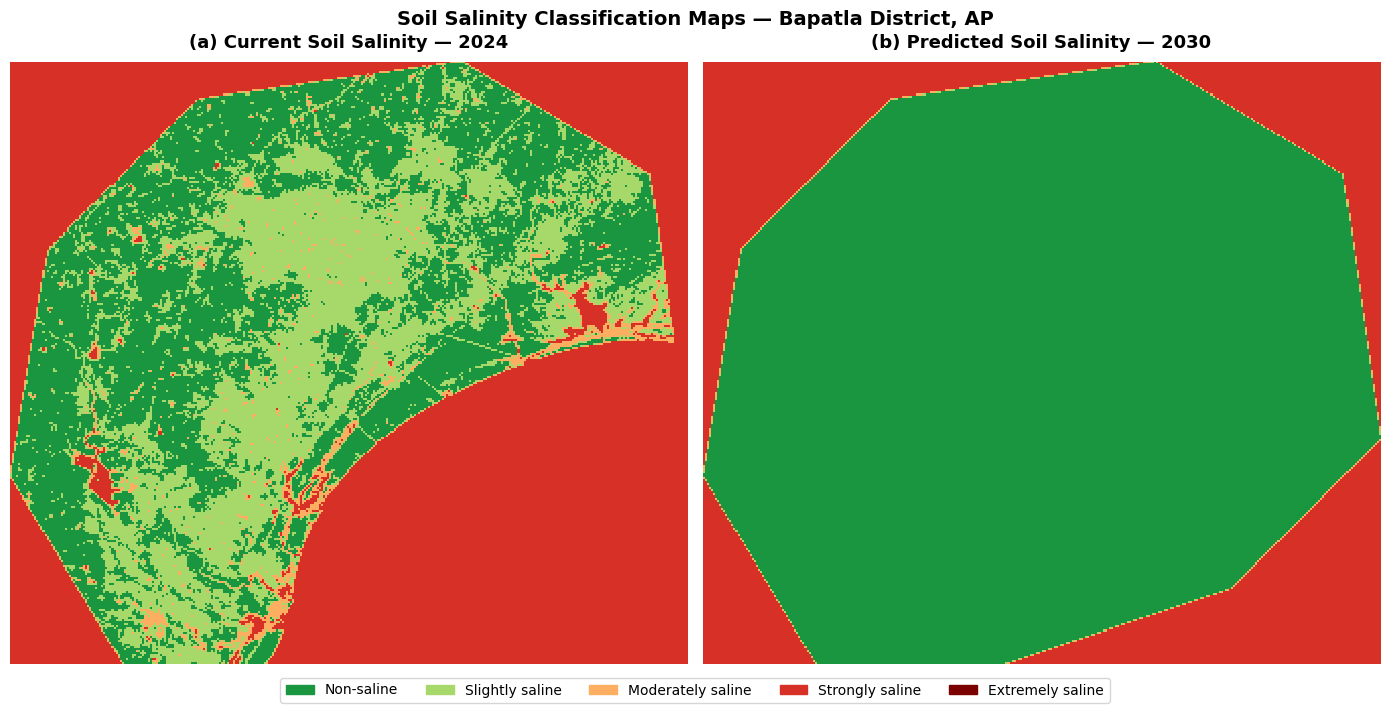

✓ Figure 1 saved (300 DPI)


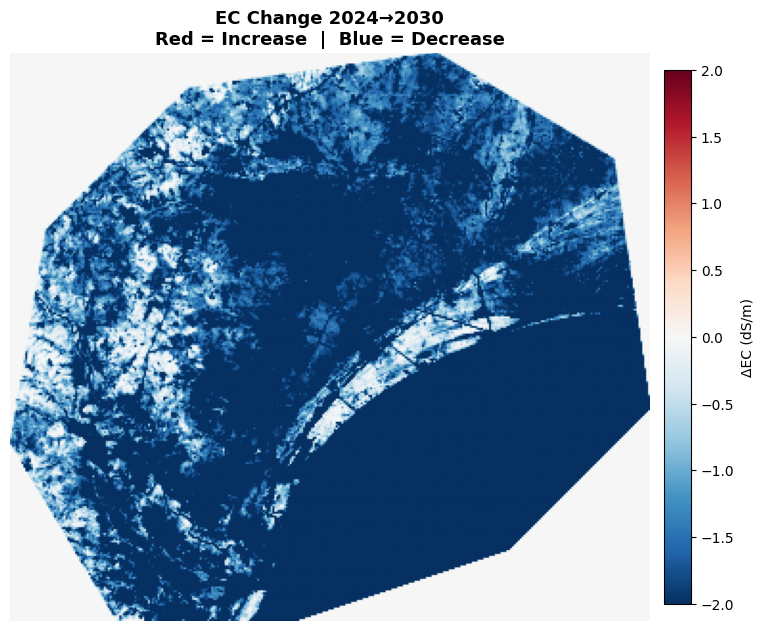

✓ Figure 2 saved (300 DPI)


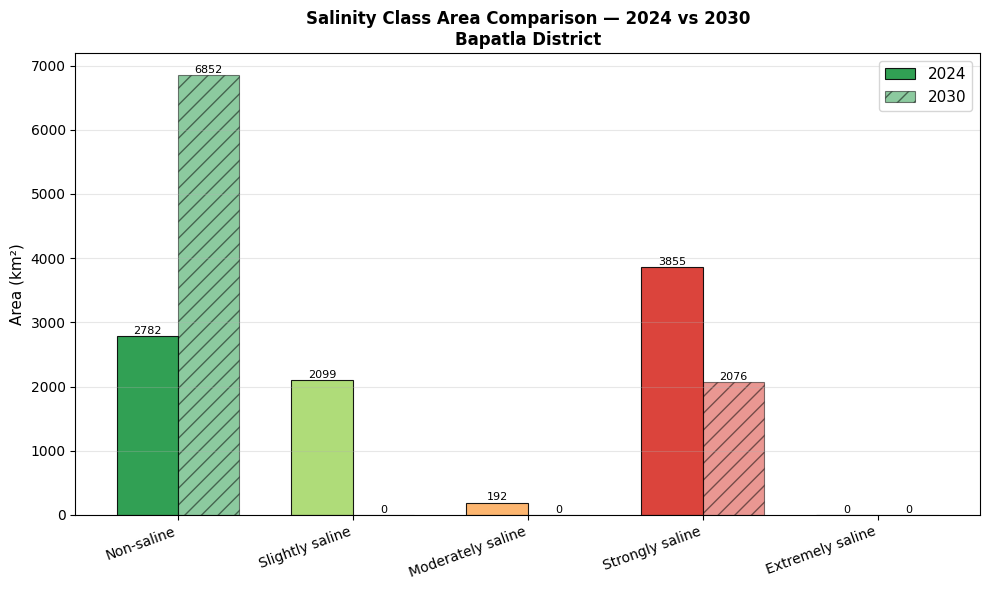

✓ Figure 3 saved (300 DPI)


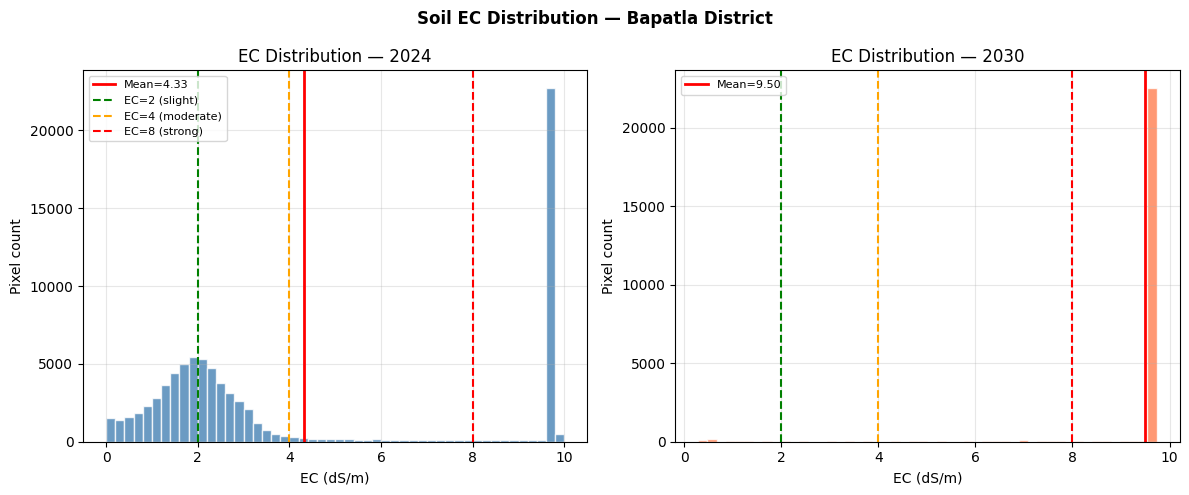

✓ Figure 4 saved (300 DPI)


In [ ]:
def read_overview(path, scale=10):
    with rasterio.open(path) as src:
        H = src.height//scale
        W = src.width//scale
        return src.read(1, out_shape=(H,W),
                       resampling=rasterio.enums.Resampling.average)

cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm([0.5,1.5,2.5,3.5,4.5,5.5], cmap.N)

ec_2024s  = read_overview('/content/data/maps/bapatla_ec_2024.tif')
ec_2030s  = read_overview('/content/data/maps/bapatla_ec_2030.tif')
cls_2024s = np.zeros_like(ec_2024s, dtype=np.uint8)
cls_2030s = np.zeros_like(ec_2030s, dtype=np.uint8)
for i in range(1,6):
    if i==1: cls_2024s[ec_2024s<2]=1;        cls_2030s[ec_2030s<2]=1
    if i==2: cls_2024s[(ec_2024s>=2)&(ec_2024s<4)]=2;  cls_2030s[(ec_2030s>=2)&(ec_2030s<4)]=2
    if i==3: cls_2024s[(ec_2024s>=4)&(ec_2024s<8)]=3;  cls_2030s[(ec_2030s>=4)&(ec_2030s<8)]=3
    if i==4: cls_2024s[(ec_2024s>=8)&(ec_2024s<16)]=4; cls_2030s[(ec_2030s>=8)&(ec_2030s<16)]=4
    if i==5: cls_2024s[ec_2024s>=16]=5;      cls_2030s[ec_2030s>=16]=5

change = ec_2030s - ec_2024s
patches = [Patch(color=c,label=n) for c,n in zip(colors,names)]

# ── Figure 1: Classification maps ────────────────────────────
fig, axes = plt.subplots(1,2, figsize=(14,7))
axes[0].imshow(cls_2024s, cmap=cmap, norm=norm, interpolation='nearest')
axes[0].set_title('(a) Current Soil Salinity — 2024',
                   fontsize=13, fontweight='bold', pad=10)
axes[0].axis('off')
axes[1].imshow(cls_2030s, cmap=cmap, norm=norm, interpolation='nearest')
axes[1].set_title('(b) Predicted Soil Salinity — 2030',
                   fontsize=13, fontweight='bold', pad=10)
axes[1].axis('off')
fig.legend(handles=patches, loc='lower center', ncol=5,
           fontsize=10, bbox_to_anchor=(0.5,-0.02))
plt.suptitle('Soil Salinity Classification Maps — Bapatla District, AP',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/data/maps/Fig1_classification_maps.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("✓ Figure 1 saved (300 DPI)")

# ── Figure 2: Change map ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(8,7))
im = ax.imshow(change, cmap='RdBu_r', vmin=-2, vmax=2)
plt.colorbar(im, ax=ax, shrink=0.8, label='ΔEC (dS/m)', pad=0.02)
ax.set_title('EC Change 2024→2030\nRed = Increase  |  Blue = Decrease',
              fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('/content/data/maps/Fig2_change_map.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("✓ Figure 2 saved (300 DPI)")

# ── Figure 3: Bar chart area comparison ──────────────────────
fig, ax = plt.subplots(figsize=(10,6))
x    = np.arange(len(names))
w    = 0.35
b1   = ax.bar(x-w/2, df_2024['area_km2'], w,
              color=colors, edgecolor='black', linewidth=0.8,
              label='2024', alpha=0.9)
b2   = ax.bar(x+w/2, df_2030['area_km2'], w,
              color=colors, edgecolor='black', linewidth=0.8,
              label='2030', alpha=0.5, hatch='//')

# Value labels on bars
for bar in b1:
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+2,
            f'{h:.0f}', ha='center', va='bottom', fontsize=8)
for bar in b2:
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+2,
            f'{h:.0f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(names, rotation=20, ha='right', fontsize=10)
ax.set_ylabel('Area (km²)', fontsize=11)
ax.set_title('Salinity Class Area Comparison — 2024 vs 2030\nBapatla District',
              fontsize=12, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('/content/data/maps/Fig3_area_comparison.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("✓ Figure 3 saved (300 DPI)")

# ── Figure 4: EC distribution histogram ──────────────────────
fig, axes = plt.subplots(1,2, figsize=(12,5))

# Read sample of EC values for histogram
with rasterio.open('/content/data/maps/bapatla_ec_2024.tif') as s:
    ec_sample = s.read(1,
        out_shape=(s.height//10, s.width//10),
        resampling=rasterio.enums.Resampling.average).flatten()
ec_sample = ec_sample[(ec_sample>0) & (ec_sample<10)]

with rasterio.open('/content/data/maps/bapatla_ec_2030.tif') as s:
    ec_sample30 = s.read(1,
        out_shape=(s.height//10, s.width//10),
        resampling=rasterio.enums.Resampling.average).flatten()
ec_sample30 = ec_sample30[(ec_sample30>0) & (ec_sample30<10)]

axes[0].hist(ec_sample,   bins=50, color='steelblue',
             edgecolor='white', alpha=0.8)
axes[0].axvline(ec_sample.mean(),   color='red', lw=2,
                label=f'Mean={ec_sample.mean():.2f}')
axes[0].axvline(2, color='green',  lw=1.5, ls='--', label='EC=2 (slight)')
axes[0].axvline(4, color='orange', lw=1.5, ls='--', label='EC=4 (moderate)')
axes[0].axvline(8, color='red',    lw=1.5, ls='--', label='EC=8 (strong)')
axes[0].set_xlabel('EC (dS/m)'); axes[0].set_ylabel('Pixel count')
axes[0].set_title('EC Distribution — 2024'); axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].hist(ec_sample30, bins=50, color='coral',
             edgecolor='white', alpha=0.8)
axes[1].axvline(ec_sample30.mean(), color='red', lw=2,
                label=f'Mean={ec_sample30.mean():.2f}')
axes[1].axvline(2, color='green',  lw=1.5, ls='--')
axes[1].axvline(4, color='orange', lw=1.5, ls='--')
axes[1].axvline(8, color='red',    lw=1.5, ls='--')
axes[1].set_xlabel('EC (dS/m)'); axes[1].set_ylabel('Pixel count')
axes[1].set_title('EC Distribution — 2030'); axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Soil EC Distribution — Bapatla District',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/data/maps/Fig4_ec_distribution.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("✓ Figure 4 saved (300 DPI)")

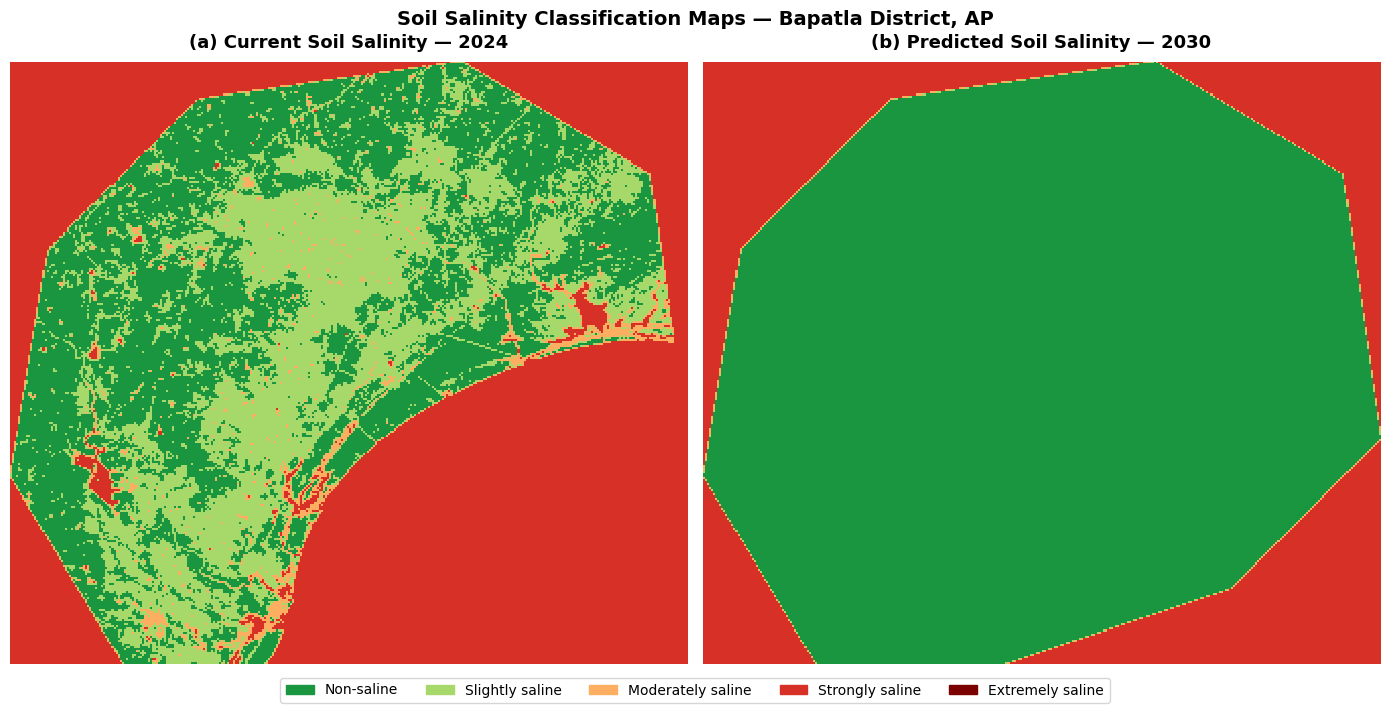

✓ Figure 1 saved (300 DPI)


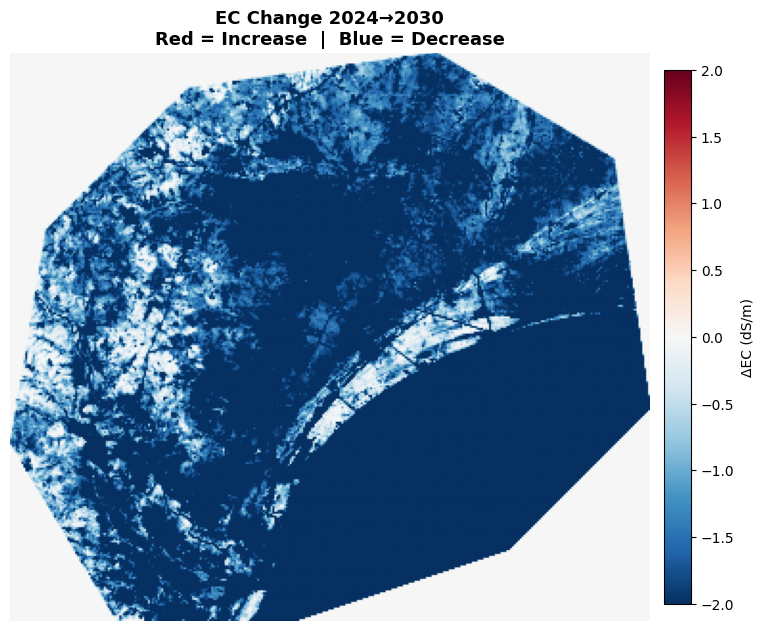

✓ Figure 2 saved (300 DPI)


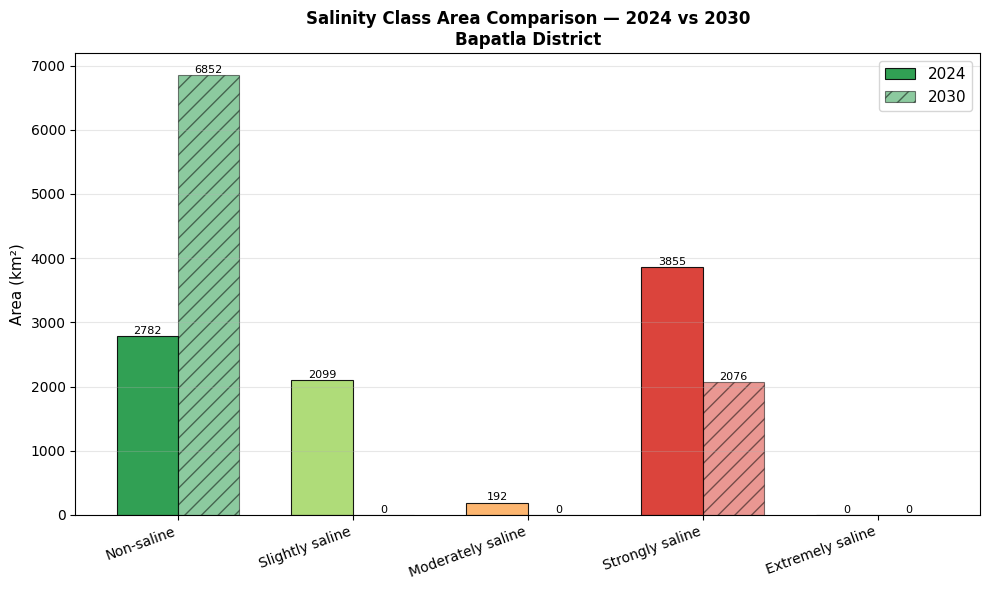

✓ Figure 3 saved (300 DPI)


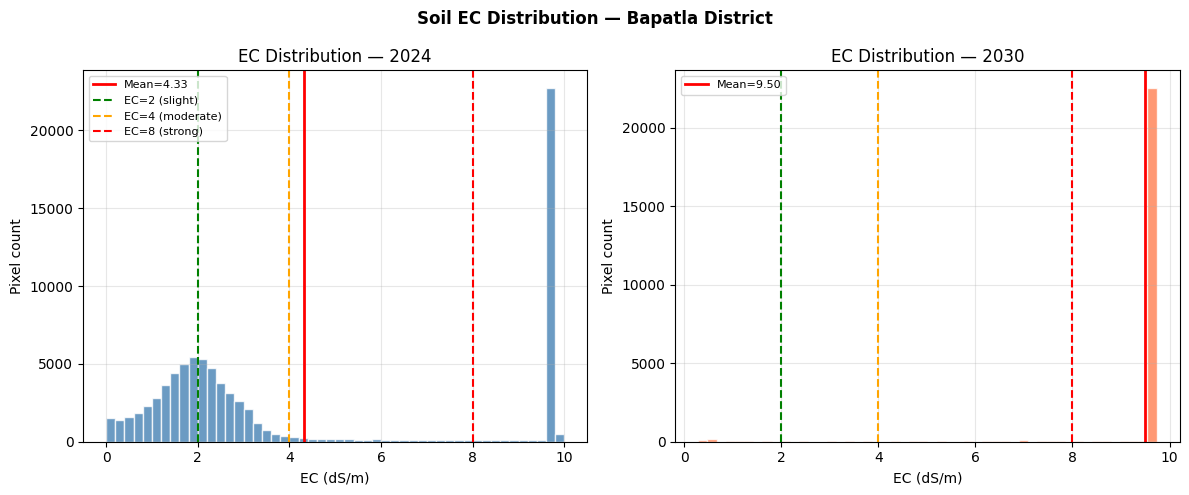

✓ Figure 4 saved (300 DPI)


In [ ]:
def read_overview(path, scale=10):
    with rasterio.open(path) as src:
        H = src.height//scale
        W = src.width//scale
        return src.read(1, out_shape=(H,W),
                       resampling=rasterio.enums.Resampling.average)

cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm([0.5,1.5,2.5,3.5,4.5,5.5], cmap.N)

ec_2024s  = read_overview('/content/data/maps/bapatla_ec_2024.tif')
ec_2030s  = read_overview('/content/data/maps/bapatla_ec_2030.tif')
cls_2024s = np.zeros_like(ec_2024s, dtype=np.uint8)
cls_2030s = np.zeros_like(ec_2030s, dtype=np.uint8)
for i in range(1,6):
    if i==1: cls_2024s[ec_2024s<2]=1;        cls_2030s[ec_2030s<2]=1
    if i==2: cls_2024s[(ec_2024s>=2)&(ec_2024s<4)]=2;  cls_2030s[(ec_2030s>=2)&(ec_2030s<4)]=2
    if i==3: cls_2024s[(ec_2024s>=4)&(ec_2024s<8)]=3;  cls_2030s[(ec_2030s>=4)&(ec_2030s<8)]=3
    if i==4: cls_2024s[(ec_2024s>=8)&(ec_2024s<16)]=4; cls_2030s[(ec_2030s>=8)&(ec_2030s<16)]=4
    if i==5: cls_2024s[ec_2024s>=16]=5;      cls_2030s[ec_2030s>=16]=5

change = ec_2030s - ec_2024s
patches = [Patch(color=c,label=n) for c,n in zip(colors,names)]

# ── Figure 1: Classification maps ────────────────────────────
fig, axes = plt.subplots(1,2, figsize=(14,7))
axes[0].imshow(cls_2024s, cmap=cmap, norm=norm, interpolation='nearest')
axes[0].set_title('(a) Current Soil Salinity — 2024',
                   fontsize=13, fontweight='bold', pad=10)
axes[0].axis('off')
axes[1].imshow(cls_2030s, cmap=cmap, norm=norm, interpolation='nearest')
axes[1].set_title('(b) Predicted Soil Salinity — 2030',
                   fontsize=13, fontweight='bold', pad=10)
axes[1].axis('off')
fig.legend(handles=patches, loc='lower center', ncol=5,
           fontsize=10, bbox_to_anchor=(0.5,-0.02))
plt.suptitle('Soil Salinity Classification Maps — Bapatla District, AP',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/data/maps/Fig1_classification_maps.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("✓ Figure 1 saved (300 DPI)")

# ── Figure 2: Change map ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(8,7))
im = ax.imshow(change, cmap='RdBu_r', vmin=-2, vmax=2)
plt.colorbar(im, ax=ax, shrink=0.8, label='ΔEC (dS/m)', pad=0.02)
ax.set_title('EC Change 2024→2030\nRed = Increase  |  Blue = Decrease',
              fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('/content/data/maps/Fig2_change_map.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("✓ Figure 2 saved (300 DPI)")

# ── Figure 3: Bar chart area comparison ──────────────────────
fig, ax = plt.subplots(figsize=(10,6))
x    = np.arange(len(names))
w    = 0.35
b1   = ax.bar(x-w/2, df_2024['area_km2'], w,
              color=colors, edgecolor='black', linewidth=0.8,
              label='2024', alpha=0.9)
b2   = ax.bar(x+w/2, df_2030['area_km2'], w,
              color=colors, edgecolor='black', linewidth=0.8,
              label='2030', alpha=0.5, hatch='//')

# Value labels on bars
for bar in b1:
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+2,
            f'{h:.0f}', ha='center', va='bottom', fontsize=8)
for bar in b2:
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+2,
            f'{h:.0f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(names, rotation=20, ha='right', fontsize=10)
ax.set_ylabel('Area (km²)', fontsize=11)
ax.set_title('Salinity Class Area Comparison — 2024 vs 2030\nBapatla District',
              fontsize=12, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('/content/data/maps/Fig3_area_comparison.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("✓ Figure 3 saved (300 DPI)")

# ── Figure 4: EC distribution histogram ──────────────────────
fig, axes = plt.subplots(1,2, figsize=(12,5))

# Read sample of EC values for histogram
with rasterio.open('/content/data/maps/bapatla_ec_2024.tif') as s:
    ec_sample = s.read(1,
        out_shape=(s.height//10, s.width//10),
        resampling=rasterio.enums.Resampling.average).flatten()
ec_sample = ec_sample[(ec_sample>0) & (ec_sample<10)]

with rasterio.open('/content/data/maps/bapatla_ec_2030.tif') as s:
    ec_sample30 = s.read(1,
        out_shape=(s.height//10, s.width//10),
        resampling=rasterio.enums.Resampling.average).flatten()
ec_sample30 = ec_sample30[(ec_sample30>0) & (ec_sample30<10)]

axes[0].hist(ec_sample,   bins=50, color='steelblue',
             edgecolor='white', alpha=0.8)
axes[0].axvline(ec_sample.mean(),   color='red', lw=2,
                label=f'Mean={ec_sample.mean():.2f}')
axes[0].axvline(2, color='green',  lw=1.5, ls='--', label='EC=2 (slight)')
axes[0].axvline(4, color='orange', lw=1.5, ls='--', label='EC=4 (moderate)')
axes[0].axvline(8, color='red',    lw=1.5, ls='--', label='EC=8 (strong)')
axes[0].set_xlabel('EC (dS/m)'); axes[0].set_ylabel('Pixel count')
axes[0].set_title('EC Distribution — 2024'); axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].hist(ec_sample30, bins=50, color='coral',
             edgecolor='white', alpha=0.8)
axes[1].axvline(ec_sample30.mean(), color='red', lw=2,
                label=f'Mean={ec_sample30.mean():.2f}')
axes[1].axvline(2, color='green',  lw=1.5, ls='--')
axes[1].axvline(4, color='orange', lw=1.5, ls='--')
axes[1].axvline(8, color='red',    lw=1.5, ls='--')
axes[1].set_xlabel('EC (dS/m)'); axes[1].set_ylabel('Pixel count')
axes[1].set_title('EC Distribution — 2030'); axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Soil EC Distribution — Bapatla District',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/data/maps/Fig4_ec_distribution.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("✓ Figure 4 saved (300 DPI)")

In [ ]:
figs = ['Fig1_classification_maps.png',
        'Fig2_change_map.png',
        'Fig3_area_comparison.png',
        'Fig4_ec_distribution.png']

print("Saving all figures to Google Drive...")
for fig in figs:
    local = f'/content/data/maps/{fig}'
    if os.path.exists(local):
        shutil.copy(local, DRIVE+fig)
        size = os.path.getsize(local)/1024
        print(f"  ✓ {fig}  ({size:.0f} KB)")

# Save tables as CSV
df_combined = df_2024.copy()
df_combined.columns = ['class_id','class_name','ec_range',
                       'pixels_2024','area_km2_2024','pct_2024']
df_combined['pixels_2030']  = df_2030['pixels'].values
df_combined['area_km2_2030'] = df_2030['area_km2'].values
df_combined['pct_2030']     = df_2030['percentage'].values
df_combined['change_km2']   = df_2030['area_km2'].values - df_2024['area_km2'].values

df_combined.to_csv('/content/data/maps/salinity_classification_table.csv', index=False)
shutil.copy('/content/data/maps/salinity_classification_table.csv',
            DRIVE+'salinity_classification_table.csv')
print("  ✓ salinity_classification_table.csv")

print(f"\n✅ ALL DONE!")
print(f"\nYour paper now has:")
print(f"  Fig1_classification_maps.png  ← Figure 3 in paper (Results)")
print(f"  Fig2_change_map.png           ← Figure 4 in paper (Results)")
print(f"  Fig3_area_comparison.png      ← Figure 5 in paper (Discussion)")
print(f"  Fig4_ec_distribution.png      ← Figure 2 in paper (Results)")
print(f"  salinity_classification_table.csv ← Table 3 in paper")
print(f"\nNext → Write the research paper!")

Saving all figures to Google Drive...
  ✓ Fig1_classification_maps.png  (169 KB)
  ✓ Fig2_change_map.png  (247 KB)
  ✓ Fig3_area_comparison.png  (214 KB)
  ✓ Fig4_ec_distribution.png  (136 KB)
  ✓ salinity_classification_table.csv

✅ ALL DONE!

Your paper now has:
  Fig1_classification_maps.png  ← Figure 3 in paper (Results)
  Fig2_change_map.png           ← Figure 4 in paper (Results)
  Fig3_area_comparison.png      ← Figure 5 in paper (Discussion)
  Fig4_ec_distribution.png      ← Figure 2 in paper (Results)
  salinity_classification_table.csv ← Table 3 in paper

Next → Write the research paper!
